In [24]:
from numpy import random
from scipy import optimize

import numpy as np
import matplotlib.pyplot as plt

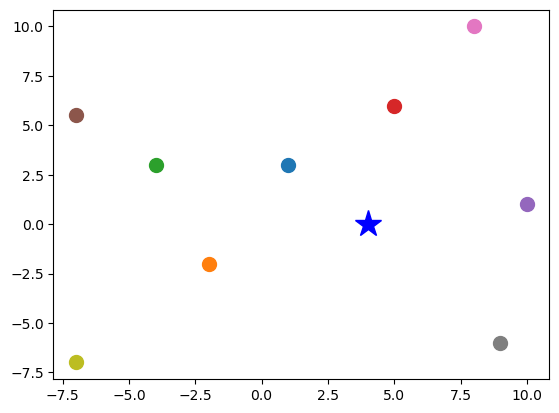

In [25]:
b = np.array([[1, -2, -4, 5, 10, -7, 8,   9, -7],
            [3, -2,  3, 6, 1, 5.5, 10, -6, -7]])

truePose = np.array([[4], [0]])

for i in range(b.shape[1]):
    plt.plot(b[0, i], b[1, i], 'o', ms=10)

plt.plot(truePose[0,0], truePose[1,0], 'b*', ms=20)

In [ ]:
def nonlinearLS(theta, b, y):
    residuals = y - np.linalg.norm(b - theta.reshape(-1,1) , axis = 0)
    return np.sum(residuals**2)

In [116]:
noise = 2.0 * np.random.randn(b.shape[1], 1)
y = np.zeros(b.shape[1])
for i in range(b.shape[1]):
    y[i] = np.linalg.norm(truePose - b[:, i].reshape(-1, 1)) + noise[i, 0]

theta0 = np.array([[0], [0]])
print("Initial guess:", theta0.shape)
print("Initial guess:", theta0.reshape(-1,1).shape)
print("b shape:", b.shape)
res = optimize.minimize(nonlinearLS, theta0.reshape(-1), args=(b, y),)
print(res)


Initial guess: (2, 1)
Initial guess: (2, 1)
b shape: (2, 9)
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 51.1921476559073
        x: [ 2.532e+00  4.735e-01]
      nit: 6
      jac: [ 5.245e-06 -2.384e-06]
 hess_inv: [[ 9.366e-02 -5.061e-04]
            [-5.061e-04  1.114e-01]]
     nfev: 24
     njev: 8


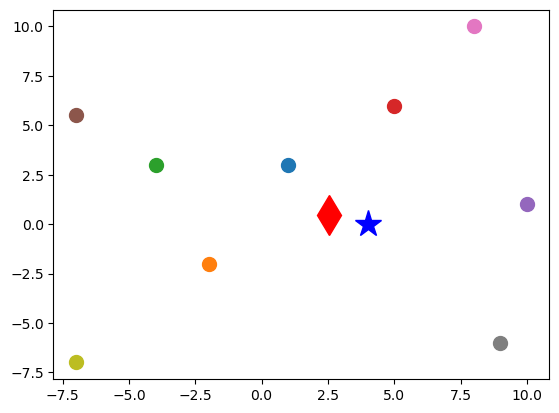

In [117]:
for i in range(b.shape[1]):
    plt.plot(b[0, i], b[1, i], 'o', ms=10)

plt.plot(res.x[0], res.x[1], 'rd', ms=20)

plt.plot(truePose[0,0], truePose[1,0], 'b*', ms=20)